In [22]:
# Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud

# Data Kagle

In [42]:
data = pd.read_csv("tokopedia_products_with_review.csv",on_bad_lines='skip',engine='python')

In [43]:
# Mengidentifikasi nama kolom
data.columns

Index(['product_id', 'category', 'name', 'count_sold', 'discounted_price',
       'preorder', 'price', 'stock', 'gold_merchant', 'is_official',
       'is_topads', 'rating_average', 'shop_id', 'shop_location',
       'warehouse_id', 'product_url', 'review_id', 'variant_name', 'message',
       'review_rating', 'review_time', 'review_timestamp', 'review_response',
       'review_like', 'bad_rating_reason'],
      dtype='object')

In [44]:
# Menghapus kolom yang tidak digunakan
data = data.drop(columns=['product_id', 'count_sold', 'discounted_price',
       'preorder', 'stock', 'gold_merchant', 'is_official',
       'is_topads', 'rating_average', 'shop_id', 'shop_location',
       'warehouse_id', 'product_url', 'review_id', 'variant_name', 'message',
       'review_rating', 'review_time', 'review_timestamp', 'review_response',
       'review_like', 'bad_rating_reason'])

# Mengubah cara penulisan
data['name'] = data['name'].str.title()
data = data.copy()

# Daftar kata kunci yang ingin dibuang
list_buang = ['hewan', 'olahraga', 'bayi', 'musik', 'gaming', 'otomotif', 'Jual', 'Promo', 'Sameday', 'Bundle']
keywords = '|'.join(list_buang)

# Membuang baris yang mengandung kata-kata di atas
data = data[~data['category'].str.contains(keywords, case=False, na=False)]

# Menghapus baris yang kategorinya persis '|'
data = data[data['category'] != '|'].copy()

# Reset index agar urutan angkanya kembali rapi
data = data.reset_index(drop=True)

# Mengubah kategori
data.loc[data['category'].str.contains('rumah_tangga|kamera|elektronik|handphone|dapur|komputer', case=False, na=False), 'category'] = 'Perlengkapan Operasional'
data.loc[data['category'].str.contains('office_stationery|buku', na=False), 'category'] = 'ATK/Administrasi'
data.loc[data['category'].str.contains('fashion', na=False), 'category'] = 'Fashion'
data.loc[data['category'].str.contains('kecantikan|kesehatan|perawatan_tubuh', na=False), 'category'] = 'Kesehatan'
data.loc[data['category'].str.contains('produk_susu_pilihan|minuman_penggugah_selera', na=False), 'category'] = 'Minuman & Bahan Minuman'
data.loc[data['category'].str.contains('sembako_pilihan_minggu_ini|siap_masak_diskon_hingga_50%|makanan_penggugah_selera|jajanan_viral|makanan_minuman', na=False), 'category'] = 'Makanan & Bahan Makanan'
data.loc[data['name'].str.contains('minuman|coffee|Kopi', na=False), 'category'] = 'Minuman & Bahan Minuman'

# Mengatur ulang urutan kolom
data = data[['name', 'price', 'category']]
data.rename(columns={'category': 'Kategori'}, inplace=True)

In [45]:
# Mengecek total data per kategori
data['Kategori'].value_counts()

,count
Kategori,
Perlengkapan Operasional,1690
Kesehatan,791
ATK/Administrasi,715
Fashion,299
Makanan & Bahan Makanan,276
Minuman & Bahan Minuman,36


# Data hasil Scraping Tokopedia

In [46]:
df1 = pd.read_csv("tokopedia_alat-kebersihan.csv")
df2 = pd.read_csv("tokopedia_alat-tulis.csv")
df3 = pd.read_csv("tokopedia_alat_kebersihan_kamar_mandi.csv")
df4 = pd.read_csv("tokopedia_produk_terasi.csv")
df5 = pd.read_csv("tokopedia_produk_Fashion.csv")
df6 = pd.read_csv("tokopedia_produk_Fashionp.csv")
df7 = pd.read_csv("tokopedia_produk_OfficeStationery.csv")
df8 = pd.read_csv("tokopedia_produk_bahan-kue.csv")
df9 = pd.read_csv("tokopedia_produk_bahan_beras.csv")
df10 = pd.read_csv("tokopedia_produk_buah.csv")
df11 = pd.read_csv("tokopedia_produk_bumbu_bawang.csv")
df12 = pd.read_csv("tokopedia_produk_bumbu_bumbu-masak-instan.csv")
df13 = pd.read_csv("tokopedia_produk_bumbu_sambal.csv")
df14 = pd.read_csv("tokopedia_produk_cuka.csv")
df15 = pd.read_csv("tokopedia_produk_daging.csv")
df16 = pd.read_csv("tokopedia_produk_daging_sosis.csv")
df17 = pd.read_csv("tokopedia_produk_garam-merica.csv")
df18 = pd.read_csv("tokopedia_produk_gula.csv")
df19 = pd.read_csv("tokopedia_produk_kaldu.csv")
df20 = pd.read_csv("tokopedia_produk_kecap.csv")
df21 = pd.read_csv("tokopedia_produk_kesehatan.csv")
df22 = pd.read_csv("tokopedia_produk_mayonnaise.csv")
df23 = pd.read_csv("tokopedia_produk_mie-pasta.csv")
df24 = pd.read_csv("tokopedia_produk_minuman.csv")
df25 = pd.read_csv("tokopedia_produk_minyak.csv")
df26 = pd.read_csv("tokopedia_produk_santan.csv")
df27 = pd.read_csv("tokopedia_produk_saus-dressing.csv")
df28 = pd.read_csv("tokopedia_produk_sayur.csv")
df29 = pd.read_csv("tokopedia_produk_susu-olahan-susu.csv")
df30 = pd.read_csv("tokopedia_produk_telur.csv")
df31 = pd.read_csv("tokopedia_produk_tepung.csv")
df32 = pd.read_csv("tokopedia_tempat-penyimpanan.csv")
df33 = pd.read_csv("tokopedia_produk_pertukangan.csv")

In [47]:
# Definisikan pembagian DataFrame berdasarkan kategori
kategori_mapping = {
    'Perlengkapan Operasional': ['df1', 'df3', 'df33', 'df32'],
    'ATK/Administrasi': ['df2', 'df7'],
    'Fashion': ['df5', 'df6'],
    'Kesehatan': ['df21'],
    'Minuman & Bahan Minuman': ['df24', 'df29']
}

# Buat list untuk menampung semua nama dataframe
df_terpetakan = set()
for list_df in kategori_mapping.values():
    df_terpetakan.update(list_df)

# Proses dan kelompokkan DataFrame
df_per_kategori = {kat: [] for kat in kategori_mapping.keys()}
df_per_kategori['Makanan & Bahan Makanan'] = [] # Untuk menampung sisanya

for i in range(1, 34):
    name_str = f'df{i}'

    # Pastikan dataframe-nya ada
    if name_str in globals():
        df_temp = globals()[name_str].copy()

        # Tentukan kategorinya
        kategori_ditemukan = False
        for kat, list_df in kategori_mapping.items():
            if name_str in list_df:
                df_temp['Kategori'] = kat
                df_per_kategori[kat].append(df_temp)
                kategori_ditemukan = True
                break

        # Jika tidak masuk list mana pun, masukkan ke kategori sisanya
        if not kategori_ditemukan:
            df_temp['Kategori'] = 'Makanan & Bahan Makanan'
            df_per_kategori['Makanan & Bahan Makanan'].append(df_temp)

# Gabungkan masing-masing kelompok menjadi 1 DataFrame utuh per Kategori
df_operasional = pd.concat(df_per_kategori['Perlengkapan Operasional'], ignore_index=True) if df_per_kategori['Perlengkapan Operasional'] else pd.DataFrame()
df_atk         = pd.concat(df_per_kategori['ATK/Administrasi'], ignore_index=True) if df_per_kategori['ATK/Administrasi'] else pd.DataFrame()
df_fashion     = pd.concat(df_per_kategori['Fashion'], ignore_index=True) if df_per_kategori['Fashion'] else pd.DataFrame()
df_kesehatan   = pd.concat(df_per_kategori['Kesehatan'], ignore_index=True) if df_per_kategori['Kesehatan'] else pd.DataFrame()
df_minuman     = pd.concat(df_per_kategori['Minuman & Bahan Minuman'], ignore_index=True) if df_per_kategori['Minuman & Bahan Minuman'] else pd.DataFrame()
df_makanan     = pd.concat(df_per_kategori['Makanan & Bahan Makanan'], ignore_index=True) if df_per_kategori['Makanan & Bahan Makanan'] else pd.DataFrame()

# Gabungkan semua data dari kagle dan hasil scraping menjadi satu Big Dataframe
df_all_categories = pd.concat([df_operasional, df_atk, df_fashion, df_kesehatan, df_minuman, df_makanan, data], ignore_index=True)

In [48]:
# Menghapus kolom yang tidak diperlukan
df_all_categories.drop(columns = ["kategori", "price_raw"], inplace=True)

# Menghapus data yang harganya lebih dari 100 jt
df_all_categories = df_all_categories[df_all_categories['price'] < 100000000]

# Definisikan list kata yang ingin dibuang
list_buang = ['promo', 'new product', 'new', 'cod', 'gratis', 'diskon', 'sale',
    'limited', 'bonus', 'beli', 'paket', 'bundle', 'murah', 'hemat',
    'tidak untuk dijual', 'not for sale', 'jakarta timur', 'sake', 'payday','jakarta', 'free', 'Tangerang Selatan',
    'alfamidi link', 'alfamidi']

def bersihkan_nama(teks):
    if not isinstance(teks, str):
        return teks

    # 1. Hapus kurung (), [], 【】, {} beserta isinya
    teks = re.sub(r'\[.*?\]|\(.*?\)|【.*?】|\{.*?\}', '', teks)

    # 2. Hapus simbol aneh di awal kalimat saja (!, ", -, /, _, dll)
    teks = re.sub(r'^[!\"_\-\/\s\d\s\d\s]+', '', teks)

    # 3. Potong keyword stuffing dan abaikan pecahan
    pola_potong = r'(?<!\d)/(?!\d)'
    if re.search(pola_potong, teks):
        teks = re.split(pola_potong, teks)[0]

    # 4. Ganti simbol sisa di tengah kalimat dengan spasi
    teks = re.sub(r'[\"_\#\*]', ' ', teks)

    # 5. Buang kata-kata tidak penting dari list_buang
    for kata in list_buang:
        teks = re.sub(rf'\b{kata}\b', '', teks, flags=re.IGNORECASE)

    # 6. Hapus spasi ganda di tengah, serta spasi di awal/akhir teks
    teks = re.sub(r'\s+', ' ', teks).strip()

    return teks

# Terapkan fungsi pembersihan ke kolom 'name'
df_all_categories['name'] = df_all_categories['name'].apply(bersihkan_nama)

# Menghapus data yang di awali bukan dengan huruf
df_all_categories = df_all_categories[df_all_categories['name'].str.contains(r'^[A-Za-z]', na=False)]

# Format kembali teks menjadi Title Case
df_all_categories['name'] = df_all_categories['name'].str.title()


In [49]:
# Mengidentifikasi data duplikat
df_all_categories[df_all_categories.duplicated]


,name,price,Kategori
61,Ember Goldy 15 Liter Pl 12,51350.0,Perlengkapan Operasional
71,Kanzler Chicken Cordon Blue 300 Gr,64900.0,Perlengkapan Operasional
85,Kanzler Singles Mini 65G,9100.0,Perlengkapan Operasional
92,Hpm Jagung Popcorn 250 Gr,11350.0,Perlengkapan Operasional
99,Superpel Yellow Reffil 770 Ml,14110.0,Perlengkapan Operasional
...,...,...,...
78486,Gillette Blue Ii Ug Hangcard 1 S,13400.0,Kesehatan
78549,Gillette Blue Ii Ug Hangcard 1'S,13400.0,Kesehatan
78559,Gillette Blue 2 Plus 3 + 1,39300.0,Kesehatan
78566,Gillette Blue 2 Plus 3 + 1,39300.0,Kesehatan


In [50]:
# Menghapus data duplikat
df_all_categories.drop_duplicates(inplace=True)

In [51]:
# Regex Makanan
pola_makanan = r'\bbakso\b|\bjeruk\b|\bkanzler\b|\bsapi\b|\bayam\b|\bbuah\b|\bsayur\b|\bindofood\b|\bkobe\b|\bcheddar\b|\bikan panjang\b'
# Regex Minuman
pola_minuman = r'\bheavenly\b|\bhilo\b|\blemon tea\b|\bindocafe\b|\bichi ocha\b|\bkapal api\b|\bkiko\b'

# Mengidentifikasi kesalahan penempatan kategori
mask_makanan = (
    df_all_categories['name'].str.contains(
        pola_makanan,
        case=False,
        na=False,
        regex=True)) & (
    df_all_categories['Kategori'] != 'Makanan & Bahan Makanan')

mask_minuman = (
    df_all_categories['name'].str.contains(
        pola_minuman,
        case=False,
        na=False,
        regex=True)) & (
    df_all_categories['Kategori'] != 'Minuman & Bahan Minuman')

jumlah_makanan = mask_makanan.sum()
jumlah_minuman = mask_minuman.sum()
print(f"Jumlah salah kategori makanan : {jumlah_makanan}")
print(f"Jumlah salah kategori minuman : {jumlah_minuman}")
print("\nContoh salah kategori makanan:")
display(df_all_categories.loc[mask_makanan,['name', 'Kategori']].head(10))
print("\nContoh salah kategori minuman:")
display(df_all_categories.loc[mask_minuman,['name', 'Kategori']].head(10))

# Melakukan perbaikan kategori
df_all_categories.loc[mask_makanan,'Kategori'] = 'Makanan & Bahan Makanan'
df_all_categories.loc[mask_minuman,'Kategori'] = 'Minuman & Bahan Minuman'

print(f"Total diperbaiki makanan : {jumlah_makanan}")
print(f"Total diperbaiki minuman : {jumlah_minuman}")


Jumlah salah kategori makanan : 615
Jumlah salah kategori minuman : 10

Contoh salah kategori makanan:


,name,Kategori
1,Kimbo Gold Plus Bakso Sapi 340 Gr - Bakso,Perlengkapan Operasional
2,Jeruk Baby Pacitan 420-440 Gr - Jeruk,Perlengkapan Operasional
10,Kanzler Singles Bakso Original 48G,Perlengkapan Operasional
14,Kanzler Singles Mini 65G,Perlengkapan Operasional
18,Kanzler Singles Bakso Hot 48Gr,Perlengkapan Operasional
20,Kanzler Singles Mini 65G,Perlengkapan Operasional
21,Indofood Bumbu Racik Sayur Lodeh 25 Gr,Perlengkapan Operasional
22,Indofood Bumbu Racik Ayam Goreng Rempah,Perlengkapan Operasional
31,Kanzler Chicken Cordon Blue 300 Gr,Perlengkapan Operasional
57,Indofood Sambal Xtra Pds 135 Ml,Perlengkapan Operasional



Contoh salah kategori minuman:


,name,Kategori
4,Heavenly Blush Ygt Greek Cup 300 Gr,Perlengkapan Operasional
67,Lemon Tea 5 X 25 Gr,Perlengkapan Operasional
74,Kiko Ice Stick 10'S X 70 Ml,Perlengkapan Operasional
80,Indocafe Coffee Mix 5Sx20G,Perlengkapan Operasional
89,Kapal Api Coffee Mix Box 5 Pcs X 25 Gr,Perlengkapan Operasional
114,Ichi Ocha Green Tea Pet 350Ml,Perlengkapan Operasional
127,Indocafe Coffee Mix 100Sx20G,Perlengkapan Operasional
497,Hilo School Susu Coklat 10 X 35 Gr,Perlengkapan Operasional
502,Kapal Api Krim Kafe Creamer 100G,Perlengkapan Operasional
601,Indocafe Coffee Mix 100Sx20G,Perlengkapan Operasional


Total diperbaiki makanan : 615
Total diperbaiki minuman : 10


In [52]:
# Memotong nama produk menjadi 3 kata
import random
def shorten(text):
    tokens = text.split()
    tokens = tokens[:random.randint(3, 6)]
    text = ' '.join(tokens)
    return text

df_all_categories['name'] = df_all_categories['name'].apply(shorten)

In [53]:
df_all_categories["Kategori"].value_counts()

,count
Kategori,
Fashion,12237
Perlengkapan Operasional,11296
Makanan & Bahan Makanan,10683
Kesehatan,10370
ATK/Administrasi,8383
Minuman & Bahan Minuman,8028


In [54]:
# Lihat jumlah per kategori
print(df_all_categories['Kategori'].value_counts())

# Cari jumlah minimum
min_count = df_all_categories['Kategori'].value_counts().min()

print(f"\nJumlah minimum tiap kategori: {min_count}")

# Random undersampling
df_balanced = (
    df_all_categories
    .groupby('Kategori', group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=42))
    .reset_index(drop=True)
)

# Cek hasil
print("\nJumlah setelah balancing:")
print(df_balanced['Kategori'].value_counts())

Kategori
Fashion                     12237
Perlengkapan Operasional    11296
Makanan & Bahan Makanan     10683
Kesehatan                   10370
ATK/Administrasi             8383
Minuman & Bahan Minuman      8028
Name: count, dtype: int64

Jumlah minimum tiap kategori: 8028

Jumlah setelah balancing:
Kategori
ATK/Administrasi            8028
Fashion                     8028
Kesehatan                   8028
Makanan & Bahan Makanan     8028
Minuman & Bahan Minuman     8028
Perlengkapan Operasional    8028
Name: count, dtype: int64


/tmp/ipykernel_2869/1676703591.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_count, random_state=42))


In [55]:
df_all_categories.to_csv("Clean Produk.csv", index=False)
df_balanced.to_csv("Clean Balanced Kategori Produk.csv", index=False)

In [56]:
df_balanced

,name,price,Kategori
0,Buku Tulis Catatan,11737.0,ATK/Administrasi
1,Plakban Opp Lakban Bodhi Bening,5260.0,ATK/Administrasi
2,Kenko Binder Clip 111 -,8000.0,ATK/Administrasi
3,Torenda Kancing Jas Small Motive Clasic,27000.0,ATK/Administrasi
4,Money Envelope Small -Angpao,35000.0,ATK/Administrasi
...,...,...,...
48163,Baut Stelan Throttle Body,30000.0,Perlengkapan Operasional
48164,Dux Ducis Case Compatible,185000.0,Perlengkapan Operasional
48165,Allefix Gunting Ranting Tanaman Dahan,18800.0,Perlengkapan Operasional
48166,Jck Betel Widia '78-2,71775.0,Perlengkapan Operasional


# EDA

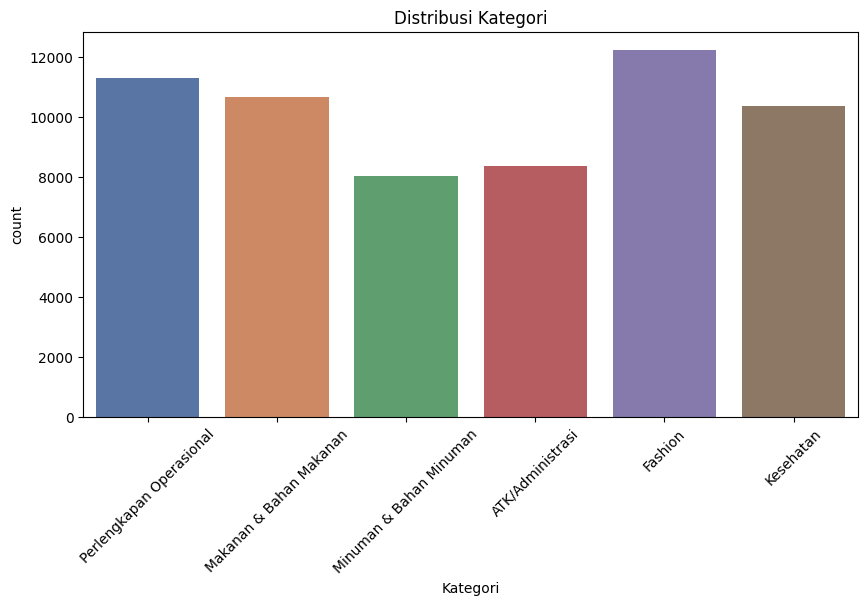

In [57]:
# Distribusi Kategori
order = (
    df_all_categories['Kategori']
    .value_counts()
    .index
)
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_all_categories,
    x='Kategori',
    hue='Kategori',
    palette='deep',
    legend=False
)

plt.xticks(rotation=45)
plt.title('Distribusi Kategori')

plt.show()

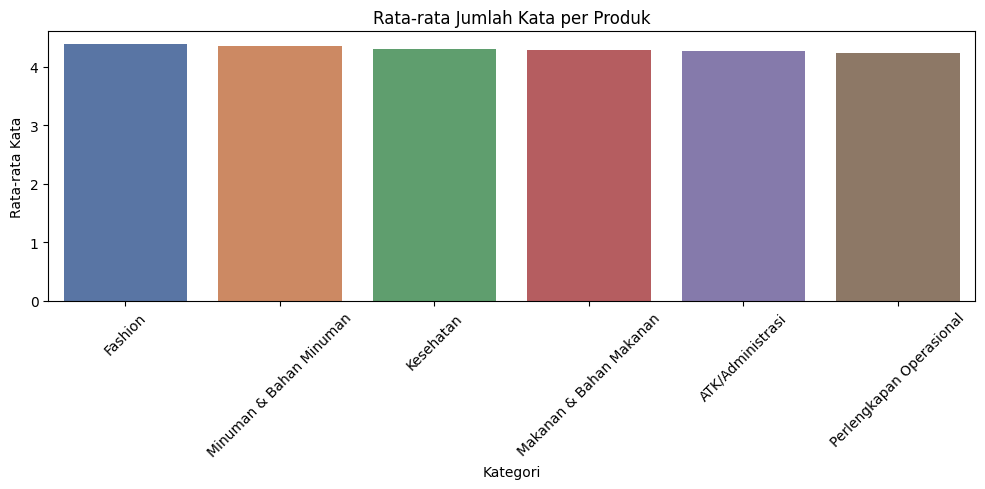

In [58]:
# Hitung jumlah kata
df_all_categories['jumlah_kata'] = (
    df_all_categories['name']
    .astype(str)
    .apply(lambda x: len(x.split()))
)

# Rata-rata kata per kategori
avg_words = (
    df_all_categories
    .groupby('Kategori')['jumlah_kata']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=avg_words,
    x='Kategori',
    y='jumlah_kata',
    hue='Kategori',
    palette='deep',   # samain palette
    legend=False
)

plt.title('Rata-rata Jumlah Kata per Produk')
plt.ylabel('Rata-rata Kata')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

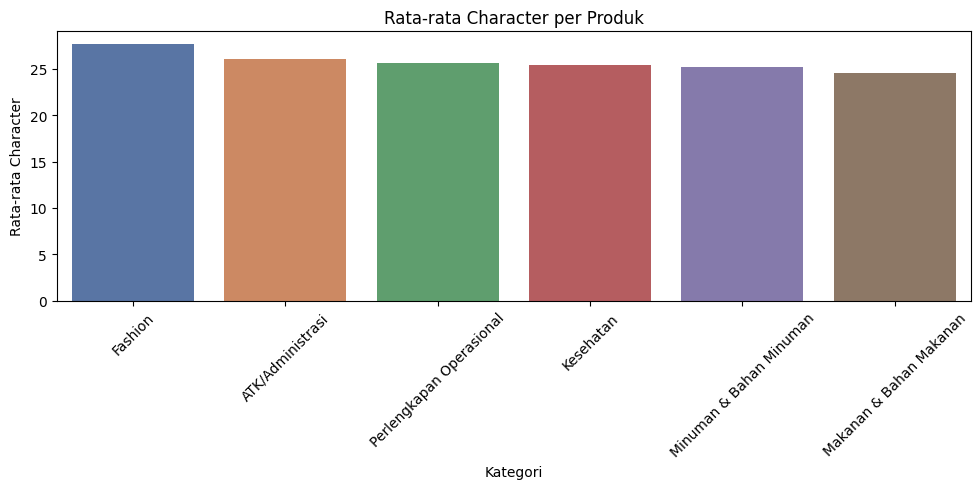

In [59]:
# Hitung jumlah character
df_all_categories['jumlah_char'] = (
    df_all_categories['name']
    .astype(str)
    .apply(len)
)

# Rata-rata char per kategori
avg_char = (
    df_all_categories
    .groupby('Kategori')['jumlah_char']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=avg_char,
    x='Kategori',
    y='jumlah_char',
    hue='Kategori',
    palette='deep',
    legend=False
)

plt.title('Rata-rata Character per Produk')
plt.ylabel('Rata-rata Character')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

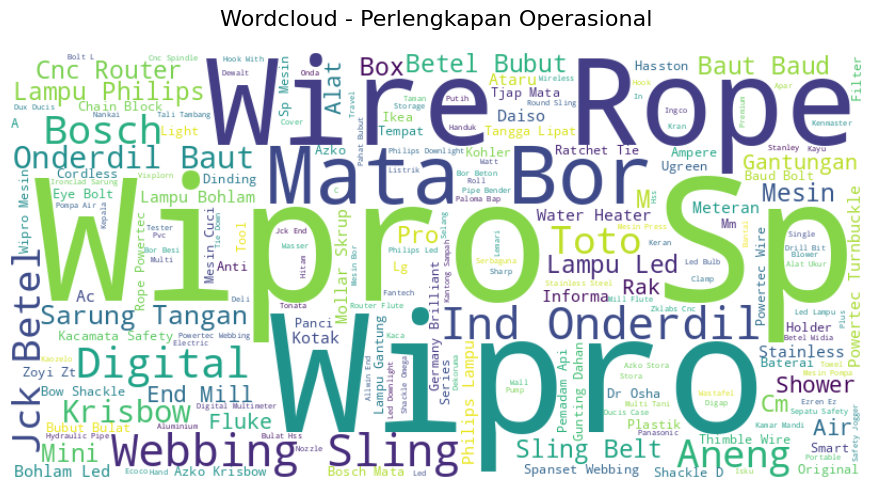

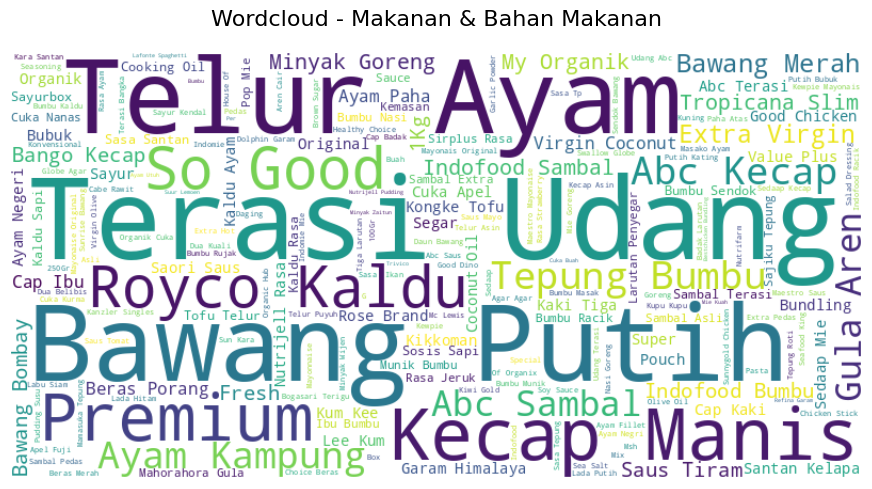

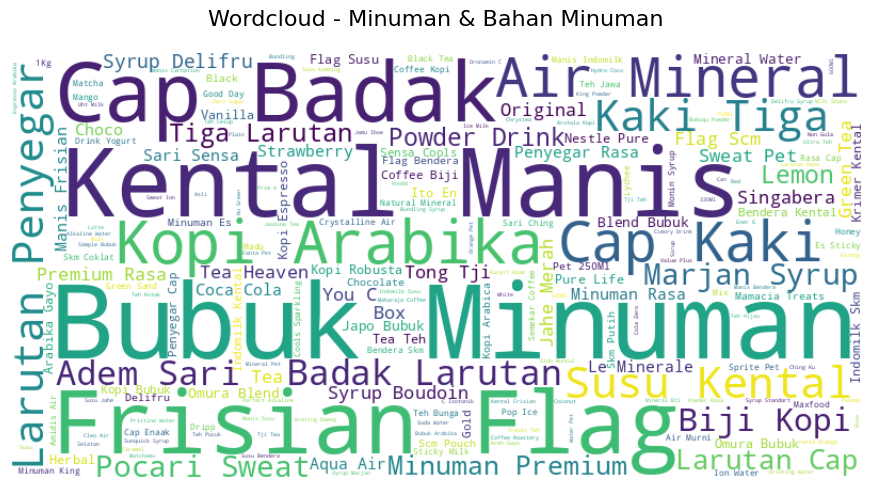

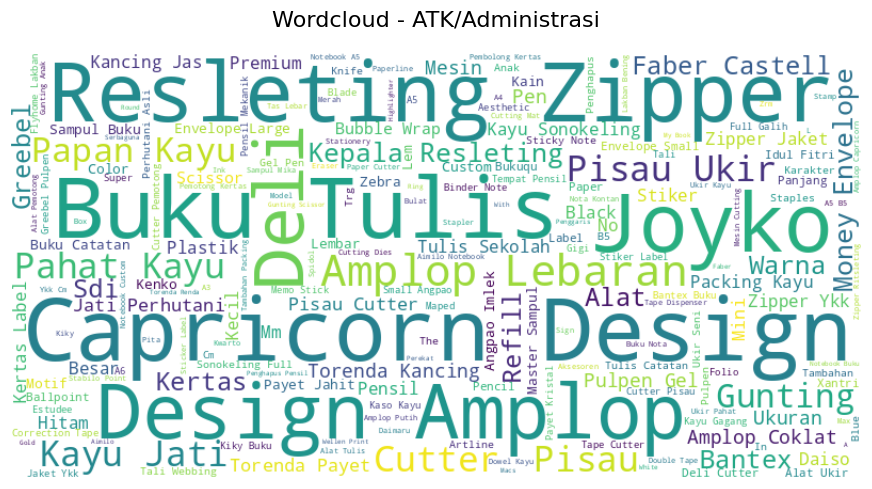

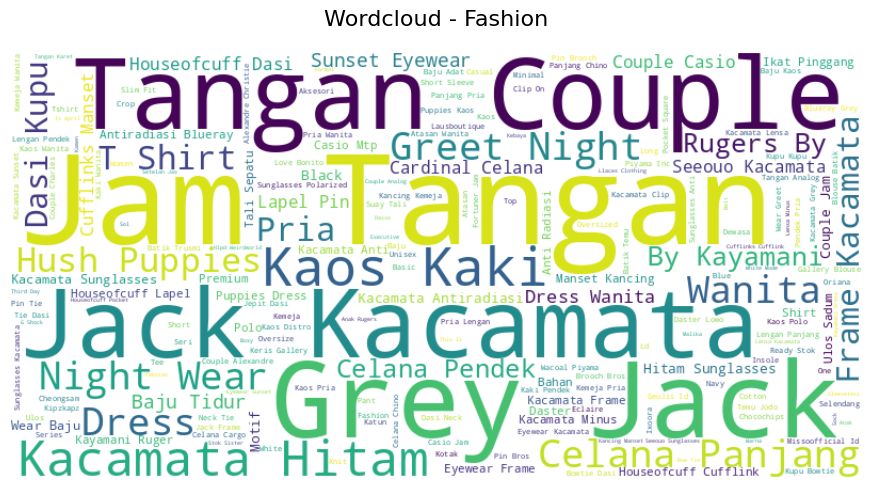

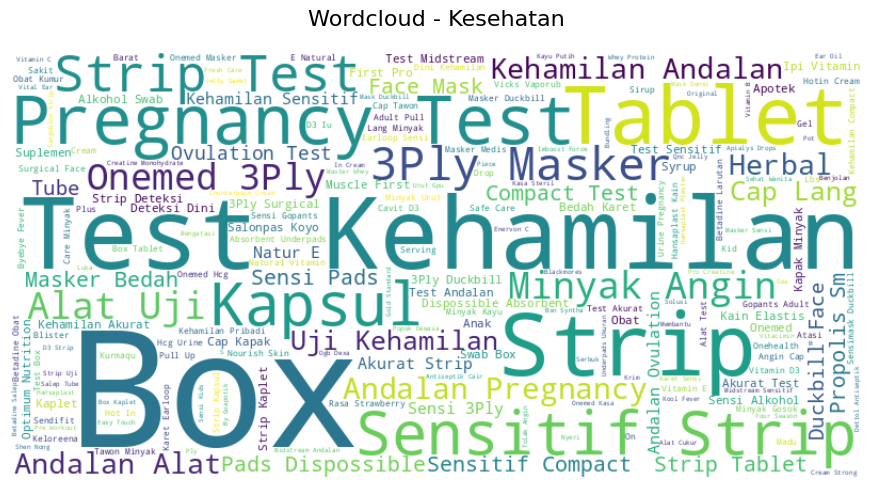

In [60]:
# Loop tiap kategori
stopwords_id = {
    'dan', 'dengan', 'untuk', 'yang', 'di', 'ke',
    'dari', 'atau',
    'isi', 'pcs', 'pack', 'pak', 'x',
    'ml', 'gr', 'kg',   '1', '2', '3', 'mg', 'gram','lb','inch','meter','lbs'
    '100ml', '200ml',
    '500gr',
    'liter',
    'botol',
    'sachet', 'type','tipe', 'set'
}

for kategori in df_all_categories['Kategori'].unique():

    # Gabungkan semua text dalam kategori
    text = ' '.join(
        df_all_categories[
            df_all_categories['Kategori'] == kategori
        ]['name'].astype(str)
    )

    # Generate wordcloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords=stopwords_id,
    ).generate(text)

    # Plot
    plt.figure(figsize=(12, 5))

    plt.imshow(
        wordcloud,
        interpolation='bilinear'
    )

    plt.axis('off')

    plt.title(
        f'Wordcloud - {kategori}',
        fontsize=16,
        pad=20
    )

    plt.tight_layout()
    plt.show()
    print('\n')

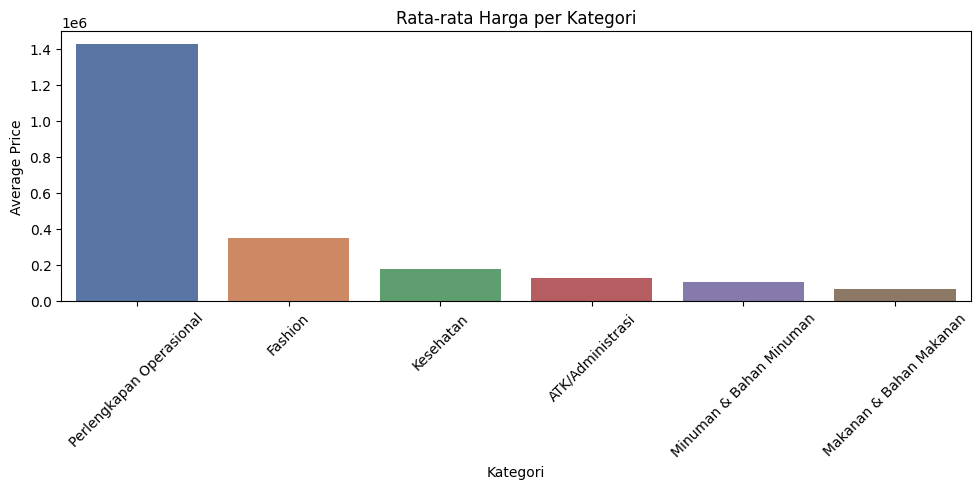

In [61]:
# Rata-rata harga per kategori
avg_price = (
    df_all_categories
    .groupby('Kategori')['price']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    data=avg_price,
    x='Kategori',
    y='price',
    hue='Kategori',
    palette='deep',
    legend=False
)

plt.title('Rata-rata Harga per Kategori')
plt.ylabel('Average Price')
plt.xlabel('Kategori')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

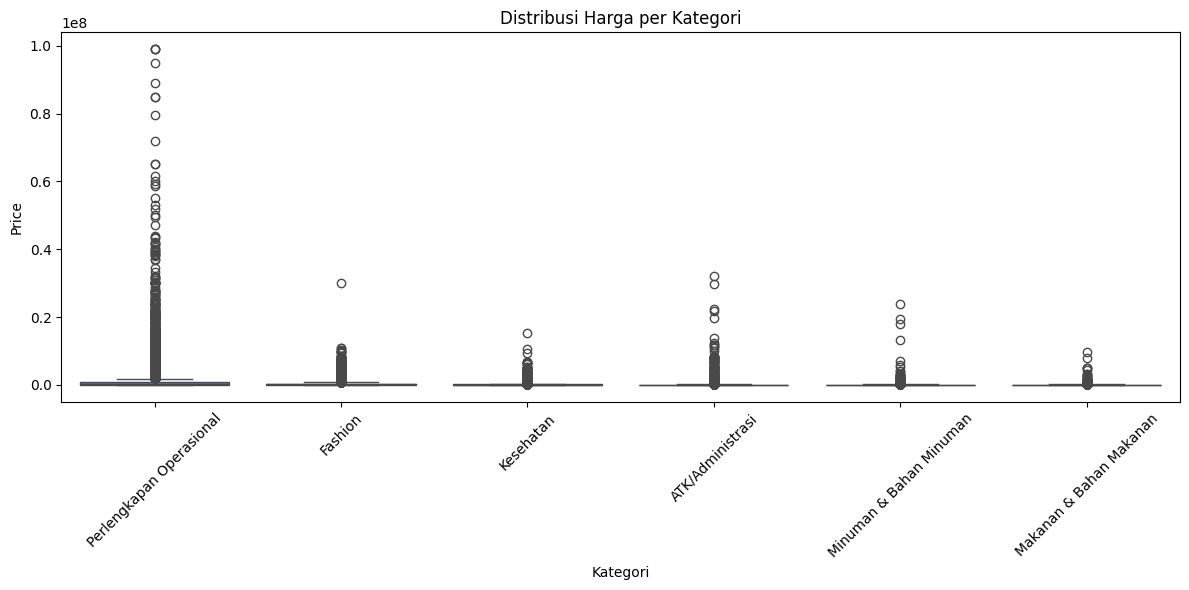

In [62]:
# Urutkan kategori berdasarkan rata-rata harga
order = (
    df_all_categories
    .groupby('Kategori')['price']
    .mean()
    .sort_values(ascending=False)
    .index
)

# Plot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_all_categories,
    x='Kategori',
    y='price',
    hue='Kategori',
    order=order,
    palette='deep',
    legend=False
)

plt.title('Distribusi Harga per Kategori')
plt.xlabel('Kategori')
plt.ylabel('Price')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [63]:
print("Produk Termahal")
print(
    df_all_categories
    .sort_values('price', ascending=False)
    [['name', 'Kategori', 'price']]
    .head(10)
)

print("\nProduk Termurah")
print(
    df_all_categories
    .sort_values('price')
    [['name', 'Kategori', 'price']]
    .head(10)
)

Produk Termahal
                                      name                  Kategori  \
8548           Tormach Pcnc440 Compact Cnc  Perlengkapan Operasional   
9064                      Tormach 770M 770  Perlengkapan Operasional   
8667          Tormach 8L Lathe Mesin Bubut  Perlengkapan Operasional   
8809                       Cnc Router 3040  Perlengkapan Operasional   
9071                    Omni 6090 Industry  Perlengkapan Operasional   
8679                 Filling Powder Sachet  Perlengkapan Operasional   
8819               Zaiku Co2 Laser Cutting  Perlengkapan Operasional   
6093   Fluke Networks Linkiq Cable+Network  Perlengkapan Operasional   
8539               Phs 1500 Plc Horizontal  Perlengkapan Operasional   
4044  Mesin Baby Roller Double Drum. Mesin  Perlengkapan Operasional   

           price  
8548  99000000.0  
9064  99000000.0  
8667  99000000.0  
8809  95000000.0  
9071  89000000.0  
8679  85000000.0  
8819  84900000.0  
6093  79565000.0  
8539  72000000.0  
4